In [19]:
from collections import defaultdict
import glob
import json

from cartopy.crs import PlateCarree, NorthPolarStereo
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from datetime import datetime, timedelta
from matplotlib.path import Path
import asf_search as asf
import pandas as pd
from scipy.ndimage import label

In [111]:
start_date = datetime(2026, 3, 1)
while start_date < datetime(2026, 4, 1):
    print(start_date)
    next_date = start_date + timedelta(days=32)
    next_date = datetime(next_date.year, next_date.month, 1)
    opts=asf.ASFSearchOptions(**{
        "bbox": [
            -179,
            60,
            179,
            89.9
        ],
        "beamSwath": [
            "EW"
        ],
        "polarization": [
            "HH+HV"
        ],
        "processingLevel": [
            "GRD_MD"
        ],
        "start": start_date.strftime("%Y-%m-%dT%H:%M:%SZ"),
        "end": next_date.strftime("%Y-%m-%dT%H:%M:%SZ"),
        "dataset": [
            "SENTINEL-1"
        ]
    })
    asf_results = asf.search(opts=opts)
    asf_results_json = asf_results.geojson()
    asf_json_filename = f'asf_results_{start_date.strftime("%Y%m%d")}.json'
    with open(asf_json_filename, 'w') as f:
        json.dump(asf_results_json, f)
    start_date = next_date

2026-03-01 00:00:00


In [112]:
idir = '/Users/antonk/Data/dmi_asip'
ifiles = sorted(glob.glob(f'{idir}/**/*.nc', recursive=True))
len(ifiles), ifiles[0], ifiles[-1]

(344,
 '/Users/antonk/Data/dmi_asip/SEAICE_ARC_PHY_AUTO_L3_MYNRT_011_023/cmems_obs-si_arc_phy_nrt_l3_P1D_202411/2025/04/dmi_asip_seaice_mosaic_arc_l3_20250401.nc',
 '/Users/antonk/Data/dmi_asip/SEAICE_ARC_PHY_AUTO_L3_MYNRT_011_023/cmems_obs-si_arc_phy_nrt_l3_P1D_202411/2026/03/dmi_asip_seaice_mosaic_arc_l3_20260310.nc')

In [113]:
min_size = 5000
min_sic_size = 3000

nps = NorthPolarStereo(central_longitude=-45, true_scale_latitude=70)
max_time_diff = 500

results = defaultdict(list)
for nfile, ifile in enumerate(ifiles):
    idate = datetime.strptime(ifile.split('/')[-1].split('_')[-1].split('.')[0], '%Y%m%d')
    print(idate)
    with xr.open_dataset(ifile) as ds:
        acq_time = ds['acq_time'][0, ::10, ::10].values
        sic = ds['sic'][0, ::10, ::10].values
        status_flag = ds['status_flag'][0, ::10, ::10].values
        xc = ds['xc'][::10].values
        yc = ds['yc'][::10].values    

    asf_date = datetime(idate.year, idate.month, 1)
    asf_json_filename = f'asf_results_{asf_date.strftime("%Y%m%d")}.json'
    with open(asf_json_filename, 'r') as f:
        asf_results_json = json.load(f)
    idate_str0 = idate.strftime("%Y-%m-%dT%H:%M:%SZ")
    idate_str1 = (idate + timedelta(1)).strftime("%Y-%m-%dT%H:%M:%SZ")
    features = [f for f in asf_results_json['features'] if f ['properties']['startTime'] >= idate_str0 and f['properties']['startTime'] < idate_str1]
    features = sorted(features, key=lambda f: f['properties']['startTime'])
    time2name = {datetime.fromisoformat(f['properties']['startTime']).timestamp(): f['properties']['sceneName'] for f in features}

    start_time = np.full(acq_time.shape, np.nan, dtype=np.float64)
    for i, feature in enumerate(features):
        coords = np.asarray(feature["geometry"]["coordinates"][0])
        xy = nps.transform_points(PlateCarree(), coords[:, 0], coords[:, 1])[:, :2]

        valid = np.isfinite(xy).all(axis=1)
        if valid.sum() < 3:
            continue

        x, y = xy[valid, 0], xy[valid, 1]
        poly_cols = (x - xc.min()) / (xc.max() - xc.min()) * (xc.size - 1)
        poly_rows = (yc.max() - y) / (yc.max() - yc.min()) * (yc.size - 1)
        poly = np.c_[poly_cols, poly_rows]

        c0 = max(0, int(np.floor(poly_cols.min())))
        c1 = min(xc.size - 1, int(np.ceil(poly_cols.max())))
        r0 = max(0, int(np.floor(poly_rows.min())))
        r1 = min(yc.size - 1, int(np.ceil(poly_rows.max())))

        if c0 > c1 or r0 > r1:
            continue

        cc, rr = np.meshgrid(np.arange(c0, c1 + 1), np.arange(r0, r1 + 1))
        pts = np.c_[cc.ravel(), rr.ravel()]
        mask = Path(poly).contains_points(pts, radius=0.5).reshape(rr.shape)

        start_time[r0:r1 + 1, c0:c1 + 1][mask] = datetime.fromisoformat(feature['properties']['startTime']).timestamp()

    time_diff = np.abs(start_time - acq_time)
    valid = time_diff < max_time_diff
    start_time[~valid] = np.nan
    ust = np.unique(start_time[np.isfinite(start_time)])
    for t in ust:
        mask = start_time == t
        scene_size = mask.sum()
        if scene_size < min_size:
            continue
        sic_size = np.isfinite(sic[mask]).sum()
        if sic_size < min_sic_size:
            continue

        rows, cols = np.nonzero(mask)
        sic_avg = np.nanmean(sic[mask])
        col_avg = np.nanmedian(cols)
        row_avg = np.nanmedian(rows)
        results['t'].append(t)
        results['sic'].append(sic_avg)
        results['col'].append(col_avg)
        results['row'].append(row_avg)
        results['size'].append(sic_size)
        results['name'].append(time2name.get(t, ''))  
    
    df = pd.DataFrame(results)
    df.to_feather('s1_stats_from_cmems.feather')


2025-04-01 00:00:00
2025-04-02 00:00:00
2025-04-03 00:00:00
2025-04-04 00:00:00
2025-04-05 00:00:00
2025-04-06 00:00:00
2025-04-07 00:00:00
2025-04-08 00:00:00
2025-04-09 00:00:00
2025-04-10 00:00:00
2025-04-11 00:00:00
2025-04-12 00:00:00
2025-04-13 00:00:00
2025-04-14 00:00:00
2025-04-15 00:00:00
2025-04-16 00:00:00
2025-04-17 00:00:00
2025-04-18 00:00:00
2025-04-19 00:00:00
2025-04-20 00:00:00
2025-04-21 00:00:00
2025-04-22 00:00:00
2025-04-23 00:00:00
2025-04-24 00:00:00
2025-04-25 00:00:00
2025-04-26 00:00:00
2025-04-27 00:00:00
2025-04-28 00:00:00
2025-04-29 00:00:00
2025-04-30 00:00:00
2025-05-01 00:00:00
2025-05-02 00:00:00
2025-05-03 00:00:00
2025-05-04 00:00:00
2025-05-05 00:00:00
2025-05-06 00:00:00
2025-05-07 00:00:00
2025-05-08 00:00:00
2025-05-09 00:00:00
2025-05-10 00:00:00
2025-05-11 00:00:00
2025-05-12 00:00:00
2025-05-13 00:00:00
2025-05-14 00:00:00
2025-05-15 00:00:00
2025-05-16 00:00:00
2025-05-17 00:00:00
2025-05-18 00:00:00
2025-05-19 00:00:00
2025-05-20 00:00:00


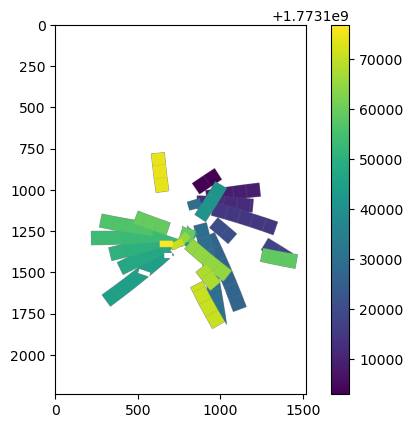

In [114]:
plt.imshow(start_time)
plt.colorbar()

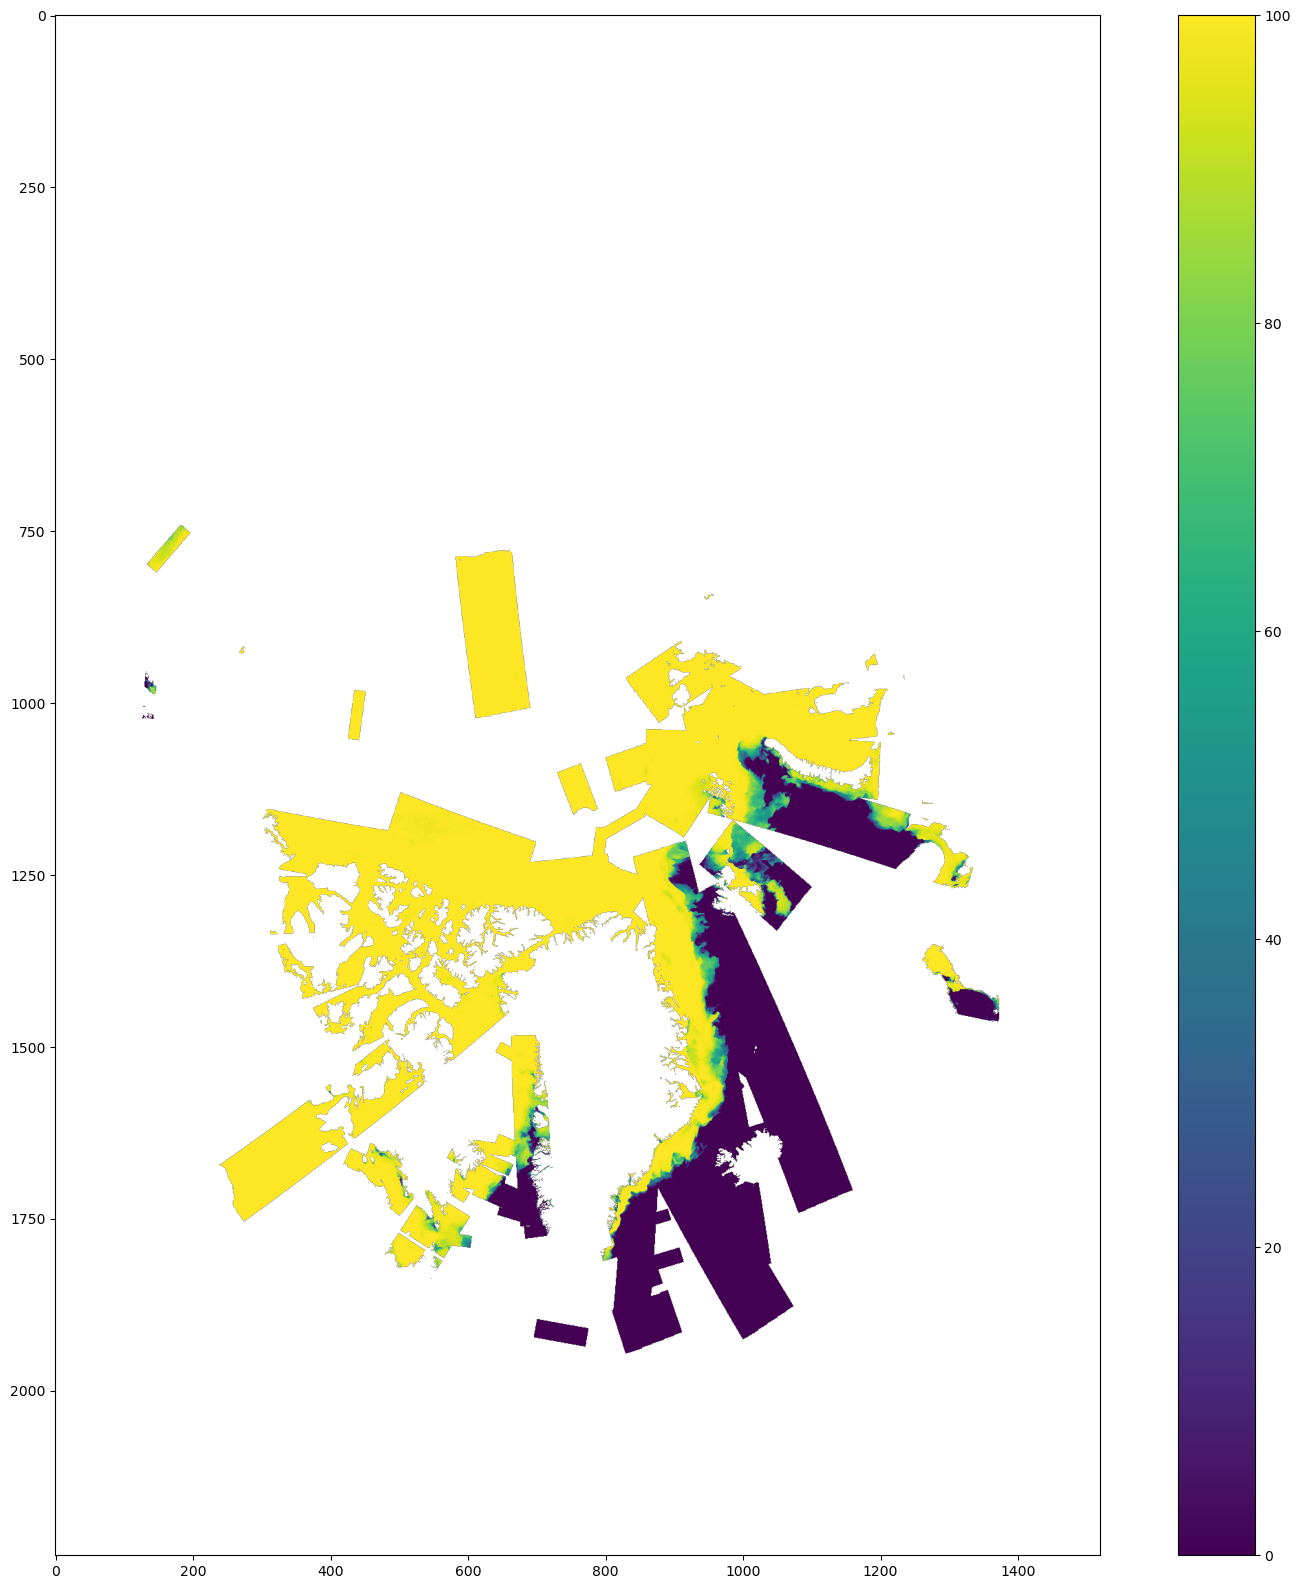

In [116]:
plt.figure(figsize=(20,20))
plt.imshow(sic)
plt.colorbar()